# Module 2: Epidemic Modeling Template

## Team Members:
Priya Shan, Owen Sines

## Module 2: Mystery Virus Analysis

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### Import Necessary Libraries 

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

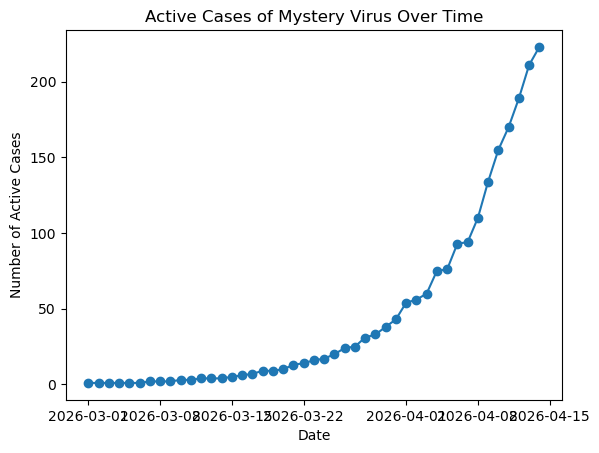

In [8]:
# Load the data
data = pd.read_csv(r'/Users/priya/Documents/Comp_Bio/GitHub/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)
# Make a plot of the active cases over time
x_values = data['date']
y_values = data['active reported daily cases']
plt.plot(x_values, y_values, marker='o')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Date') 
plt.ylabel('Number of Active Cases') 
plt.show() 

What do you notice about the initial infections? Seems to be following an exponential growth pattern 

How could we measure how quickly its spreading? Find the rate of growth of the curve 

What information about the virus would be helpful in determining the shape of the
outbreak curve? 

In [9]:
#Estimating the initial growth rate of the epidemic R0 from the early day 
def exponential_growth(t, r): #define exponential growth function to fit the data to 
    return np.exp(r * t)

x_values = data['day'] #set the x-values to the day from the initial outbreak instead of date 

popt, pcov = curve_fit(exponential_growth, x_values, y_values) #curve_fit uses non-linear least squares to fit a mathematical function to a set of data points
#function returns popt, which contains the optimal values for the parameters of the function (in this case, the growth rate r), and pcov, which is the covariance of the parameter estimates
r_estimated = popt[0] #extract the estimated growth rate from the optimal parameters
#predict intial growth rate given that the infectious period is 2 days 
R0_estimate = exponential_growth(2, r_estimated) #calculate the estimated number of cases after 1 day using the estimated growth rate
print(f"Estimated growth rate (r): {r_estimated}")
print(f"Estimated Initial Growth Rate: {R0_estimate}")



Estimated growth rate (r): 0.12144675524793189
Estimated Initial Growth Rate: 1.2749328499223294


What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.

How accurate do you think your R0 estimate is?

Plotting the estimated exponential curve over the scatterplot

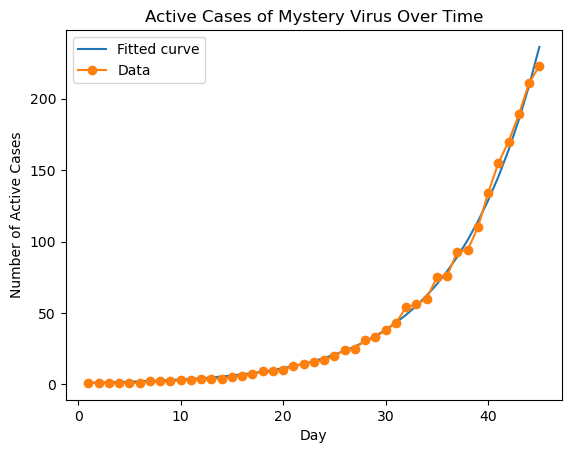

In [10]:
plt.plot(x_values, exponential_growth(x_values, popt), label='Fitted curve')
plt.plot(x_values, y_values, marker='o', label='Data')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
plt.legend()
plt.show()


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

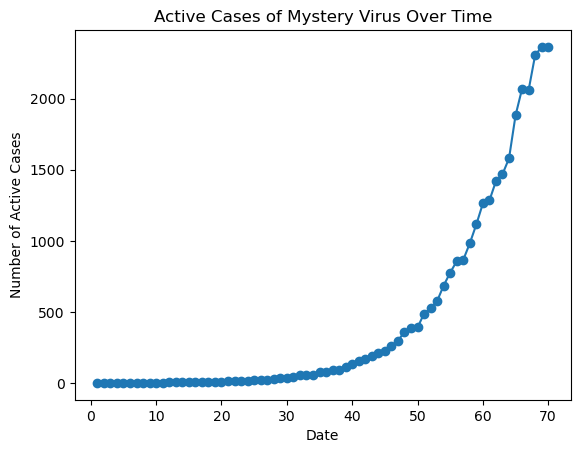

In [11]:
#Load data from release #2
data = pd.read_csv(r'/Users/priya/Documents/Comp_Bio/GitHub/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv', parse_dates=['date'], header=0, index_col=None)
#Make a plot of new active cases over time 
x_values = data['day']
y_values = data['active reported daily cases']
plt.plot(x_values, y_values, marker='o')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Date') 
plt.ylabel('Number of Active Cases') 
plt.show() 

In [12]:
'''
INPUTS: beta, sigma, gamma, S0, E0, I0, R0, timepoints, N
Initialize S, E, I, and R as empty arrays or lists
Set first item in each list equal to initial values S0, E0, I0, R0
 '''
def seir_euler(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    dt = timepoints[1] - timepoints[0]
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    #add initial value to first index of each list
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0
    #for each timepoint in timepoints: 
    for t in range(len(timepoints)-1):
        #Calculate the four derivatives at timepoint
        dS = - (beta * S[t] * I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])
      #  Calculate S, E, I, and R at timepoint + 1 using Euler’s method
        S[t+1] = S[t] + dS * dt
        E[t+1] = E[t] + dE * dt
        I[t+1] = I[t] + dI * dt
        R[t+1] = R[t] + dR * dt  
    return S, E, I, R

N = 17900 #population size at UVA 
S0 = N-40
E0 = 40 #assumption for now, will be accounted for by grid search optimization 
I0 = 1
R0 = 0

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [13]:
#Grid search optimization 
#Initialize a range for beta, sigma, and gamma
beta_range = np.linspace(0.1, 1.5, 10) #beta = R0 / D = 1.274 / 2 = 0.637, so we want to search around that value
sigma_range = np.linspace(0.055, 0.09, 5) #based on incubation period of 12-18 days, so sigma = 1 / incubation period = 1/12 to 1/18
gamma_range = np.linspace(0.1, 0.7, 10) #recovery rate = 1/2 = 0.5, so we want to search around that value 
#Initialize an empty array of SSE
best_sse = float('inf')
best_params = (0,0,0)
#search through each range of values for beta, sigma, and gamma
for b in beta_range:
    for g in gamma_range:
        for s in sigma_range:
#Use the Euler method function to calculate S, E, I, and R given those parameters
            S, E, I, R = seir_euler(b, s, g, S0, E0, I0, R0, x_values, N)
#Calculate the SSE given the model results and the data and append this to the SSE array	
            sse = np.sum((I - y_values)**2)
            if sse < best_sse:
                best_sse = sse
                best_params = (b, s, g)
#Determine parameters corresponding to lowest SSE
#Return best_beta, best_sigma, and best_gamma and corresponding SSE
best_beta, best_sigma, best_gamma = best_params
print(f"Best beta: {best_beta}, Best sigma: {best_sigma}, Best gamma: {best_gamma}, SSE: {best_sse}")

Best beta: 0.5666666666666667, Best sigma: 0.055, Best gamma: 0.1, SSE: 1001817.4889658531


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

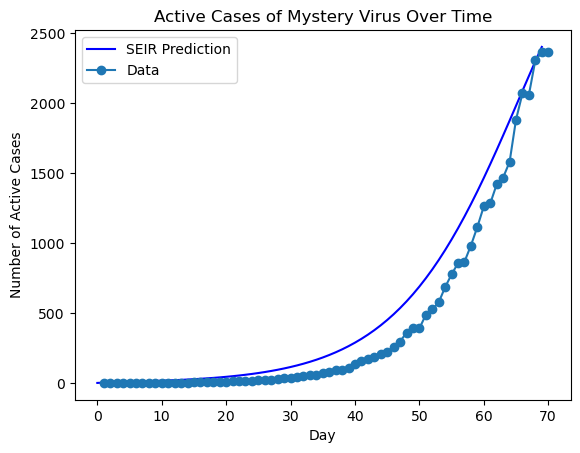

In [14]:
timepoints_70 = np.arange(0, 70, 1)
S, E, I, R = seir_euler(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, timepoints_70, N)
plt.plot(timepoints_70, I, 'b-', label='SEIR Prediction')
plt.plot(x_values, y_values, marker='o', label='Data')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
plt.legend() 
plt.show() 

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


In [15]:
future_timepoints = np.arange(0, 150, 1) #extrapolate past the given data points to predict the future 
S_f, E_f, I_f, R_f = seir_euler(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, future_timepoints, N)
peak_idx = np.argmax(I_f)
peak_day = future_timepoints[peak_idx]
peak_cases = I_f[peak_idx]
print(f"Predicted peak day: {peak_day}")
print(f"Predicted peak cases: {peak_cases}")

Predicted peak day: 83
Predicted peak cases: 3191.4875116963453



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


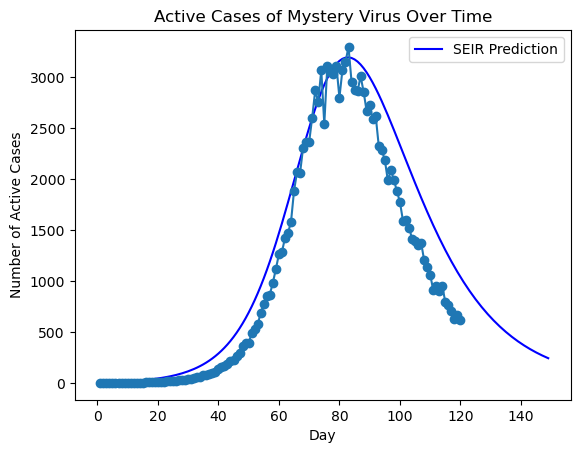

In [16]:
data = pd.read_csv(r'/Users/priya/Documents/Comp_Bio/GitHub/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv', parse_dates=['date'], header=0, index_col=None)
x_values = data['day']
y_values = data['active reported daily cases']
plt.plot(future_timepoints, I_f, 'b-', label='SEIR Prediction')
plt.plot(x_values, y_values, marker='o')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
plt.legend()
plt.show()

### Percent Error with SEIR Model 
Percent Error for Peak Number of Cases: 3191.49 - 3294 / 3191.49 = 3.211%

Percent Error for Peak Day: 83-83/83 = 0%

discuss why your model has the error it does (i.e. model limitations) and whether the error level is too high to trust your predictions


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



In [ ]:
#updated SEIR model method to include intervention scenarios
def seir_euler_intervention(beta1, beta2, sigma, gamma, gamma2, S0, E0, I0, R0, timepoints, N, vax_rate=0):
    
    dt = timepoints[1] - timepoints[0]
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    #add initial value to first index of each list
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0
#use for loop logic to iterate and know when to implement interventions 
    for t in range(len(timepoints)-1):
        current_time = timepoints[t]
        #switch at day 70
        if current_time < 69:
            beta = beta1
            gamma = gamma
            vaccinated = 0
        else:
            beta = beta2
            gamma = gamma2
            vaccinated = min(vax_rate * dt, S[t])  #multiply vaccination rate by dt to get number of people vaccinated in that time step, but can't vaccinate more people than are currently susceptible
        dS = - (beta * S[t] * I[t]) / N - vaccinated #remove vaccinated individuals from susceptible population
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t]) + vaccinated #add vaccinated individuals to recovered population
        S[t+1] = S[t] + dS * dt
        E[t+1] = E[t] + dE * dt
        I[t+1] = I[t] + dI * dt
        R[t+1] = R[t] + dR * dt

    return S, E, I, R


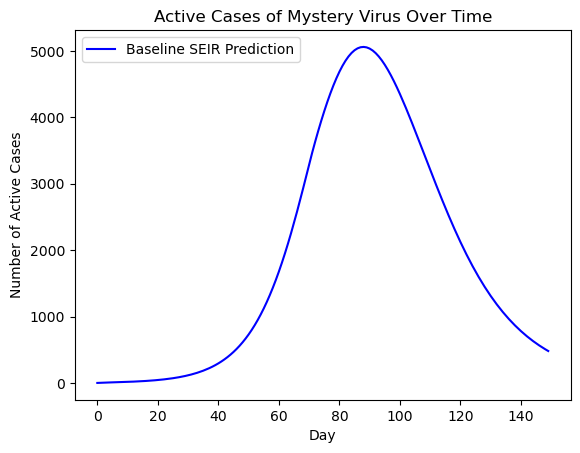

In [20]:
N_VT = 31000 #population size at VT
S0_VT = N_VT-40
E0_VT = 40 #assumption for now, will be accounted for by grid search optimization 
I0_VT = 1
R0_VT = 0
beta2 = 0.8 * best_beta #assumption that intervention reduces transmission rate by 50%, can adjust this based on the specific intervention being modeled
S_baseline, E_baseline, I_baseline, R_baseline = seir_euler_intervention(best_beta, beta2, best_sigma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT, 50)
plt.plot(future_timepoints, I_baseline, 'b-', label='Baseline SEIR Prediction')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
plt.legend()
plt.show()

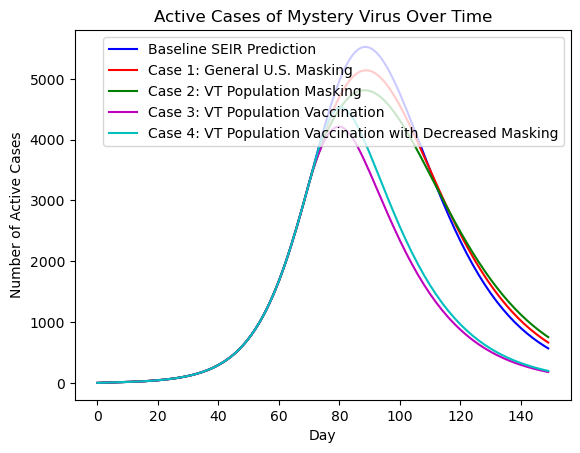

In [29]:
#Baseline Prediction for new outbreak at VT 
#We expect the peak to be higher at VT than at UVA because of the larger population size, but we also expect the peak to occur later because the initial number of cases is lower and it will take longer for the virus to spread through the population.
N_VT = 31000 #population size at VT
S0_VT = N_VT-40
E0_VT = 40 #assumption for now, will be accounted for by grid search optimization 
I0_VT = 1
R0_VT = 0
S_baseline, E_baseline, I_baseline, R_baseline = seir_euler(best_beta, best_sigma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT)
plt.plot(future_timepoints, I_baseline, 'b-', label='Baseline SEIR Prediction')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
#Intervention scenario 1: Testing effect of masking on the outbreak 
#Case 1: Masking reduces the transmission rate by __% (based on how likely general U.S. population is to wear masks) 
case_1_beta = best_beta *(1-(0.5*0.4)) #assumption that masking reduces transmission rate by 50%, can adjust this based on the specific intervention being modeled
S_case1, E_case1, I_case1, R_case1 = seir_euler_intervention(best_beta, case_1_beta, best_sigma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT)
plt.plot(future_timepoints, I_case1, 'r-', label='Case 1: General U.S. Masking')
#Case 2: Masking reduces the transmission rate by __% (based on how likely VT population is to wear masks)
case_2_beta = best_beta *(1-(0.85*0.4)) #assumption that masking reduces transmission rate by 15%, can adjust this based on the specific intervention being modeled
S_case2, E_case2, I_case2, R_case2 = seir_euler_intervention(best_beta, case_2_beta, best_sigma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT)
plt.plot(future_timepoints, I_case2, 'g-', label='Case 2: VT Population Masking')
#Intervention scenario 2: Testing effect of vaccines and masking on the outbreak
#Case 3: Vaccinations with a rate of 500 people per day with the same 85% masking compliance as VT population
S_case3, E_case3, I_case3, R_case3 = seir_euler_intervention(best_beta, case_2_beta, best_sigma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT, 1000)
plt.plot(future_timepoints, I_case3, 'm-', label='Case 3: VT Population Vaccination')
#Case 4: Case 3 updated with realistically lower masking compliance 
#During vaccination rollout, masking compliance is likely to decrease because people will feel safer and less likely to wear masks
#Between April and June 2021, mask wearing at work or school declined among both those vaccinated (74% to 49%) and unvaccinated (46% to 35%)
#average of those declines is about 51% decrease in masking compliance 
case_4_beta = 1.5*case_2_beta #assumption that masking reduces transmission rate by 50%
S_case4, E_case4, I_case4, R_case4 = seir_euler_intervention(best_beta, case_4_beta, best_sigma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT, 1000)
plt.plot(future_timepoints, I_case4, 'c-', label='Case 4: VT Population Vaccination with Decreased Masking')
plt.legend()
plt.show()


References for Literature Used in Designing Intervention Strategies 

Intervention 1 (Case 1+2): 
https://pmc.ncbi.nlm.nih.gov/articles/PMC8648375/#:~:text=Overall%2C%20a%20higher%20proportion%20of%20women%20wore,wore%20masks%20compared%20to%20nonstudents%20(Table%201). 

Intervention 2 (Case 3+4): https://pmc.ncbi.nlm.nih.gov/articles/PMC9530007/#:~:text=As%20COVID%2D19%20vaccination%20levels,the%20delta%20variant%20%5B2%5D.
Intervention 3 (Case 5): 

## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*